In [1]:
pip install whitebox

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.0/74.0 kB 3.6 MB/s eta 0:00:00


In [27]:
pip install gdal

# Making the output folder

In [2]:
import os

output_dir = "outputs"

# Create folder
os.makedirs(output_dir, exist_ok=True)

print("✅ Output folder ready:", os.path.abspath(output_dir))

✅ Output folder ready: /content/outputs


# Reading the DTM

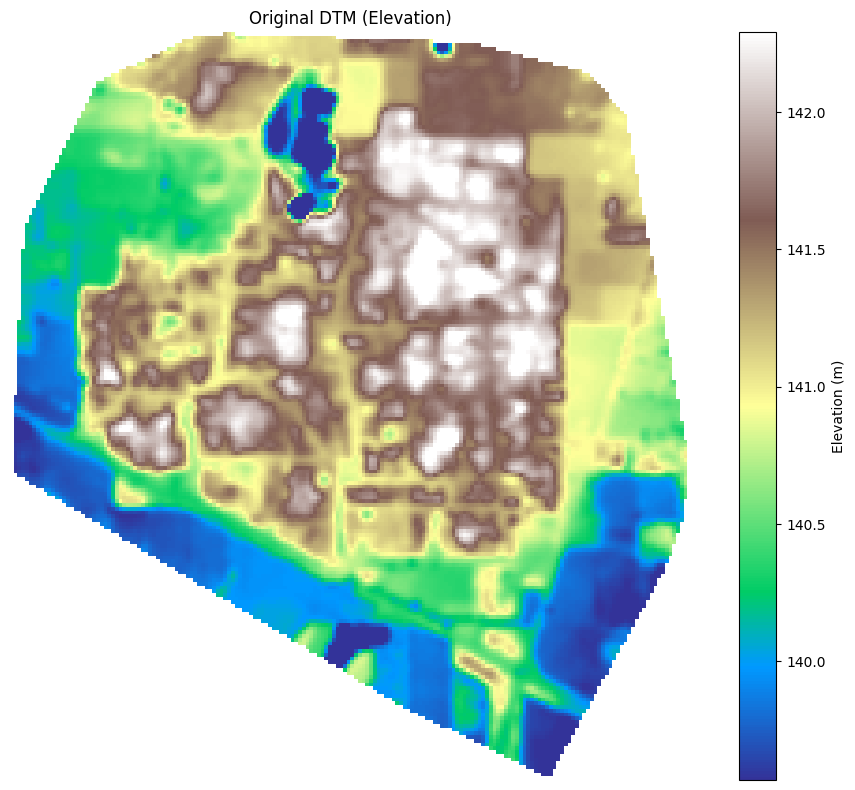

In [3]:
import matplotlib.pyplot as plt
import rasterio
import numpy as np

# Load raster which is derived form the .las classified file
with rasterio.open("dem.tif") as src:
    dem = src.read(1).astype("float32")
    nodata = src.nodata

# Handle NoData
if nodata is not None:
    dem[dem == nodata] = np.nan

# ==========================================================
# 1️⃣ PLOT: ORIGINAL DEM (NO HILLSHADE)
# ==========================================================
plt.figure(figsize=(10, 8))

plt.imshow(
    dem,
    cmap="terrain",
    vmin=np.nanpercentile(dem, 2),
    vmax=np.nanpercentile(dem, 98)
)

plt.colorbar(label="Elevation (m)")
plt.title("Original DTM (Elevation)")
plt.axis("off")
plt.tight_layout()
plt.show()



# Install Whitebox Tools

In [4]:
import os

from whitebox.whitebox_tools import WhiteboxTools


current_dir = os.getcwd()

wbt = WhiteboxTools()
wbt.set_working_dir(current_dir)
wbt.verbose = True


Decompressing WhiteboxTools_linux_musl.zip ...
WhiteboxTools package directory: /usr/local/lib/python3.12/dist-packages/whitebox


In [6]:
import rasterio
from rasterio.crs import CRS

with rasterio.open("dem.tif") as src:
    meta = src.meta.copy()
    data = src.read(1)

meta.update({"crs": CRS.from_epsg(32644)})

with rasterio.open("raster_georef.tif", "w", **meta) as dst:
    dst.write(data, 1)

# Fill Depressions

./whitebox_tools --run="FillDepressions" --wd="/content" --dem='/content/dem.tif' --output='/content/outputs/dtm_filled.tif' --fix_flats -v --compress_rasters=False

******************************
* Welcome to FillDepressions *
* Powered by WhiteboxTools   *
* www.whiteboxgeo.com        *
******************************
Reading data...
Finding pit cells: 50%
Finding pit cells: 100%
Filling depressions: 0%
Filling depressions: 1%
Filling depressions: 2%
Filling depressions: 3%
Filling depressions: 4%
Filling depressions: 5%
Filling depressions: 6%
Filling depressions: 7%
Filling depressions: 8%
Filling depressions: 9%
Filling depressions: 10%
Filling depressions: 11%
Filling depressions: 12%
Filling depressions: 13%
Filling depressions: 14%
Filling depressions: 15%
Filling depressions: 16%
Filling depressions: 17%
Filling depressions: 18%
Filling depressions: 19%
Filling depressions: 20%
Filling depressions: 21%
Filling depressions: 22%
Filling depressions: 23%
Filling depressions: 24%
F

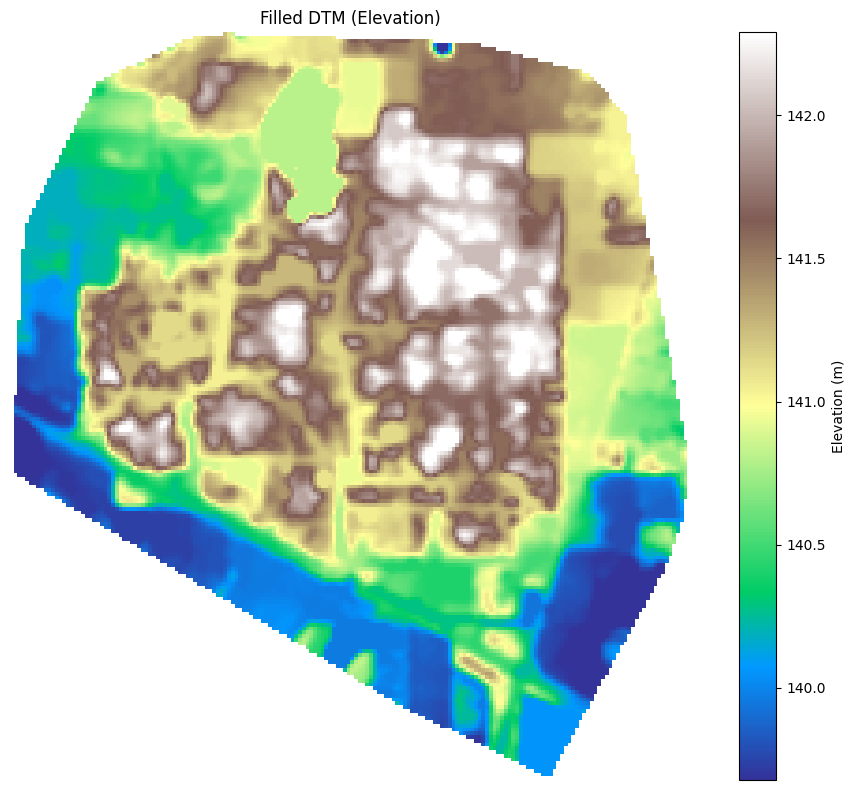

In [8]:
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt

filled_tif = os.path.abspath(os.path.join(output_dir, "dtm_filled.tif"))
input_dem = os.path.abspath("dem.tif")

# ==========================================================
# ✅ FILL DEPRESSIONS
# ==========================================================
wbt.fill_depressions(
    dem=input_dem,
    output=filled_tif
)

print("✅ Saved to:", filled_tif)



# ==========================================================
# ✅ LOAD FILE
# ==========================================================
with rasterio.open(filled_tif) as src:
    dem = src.read(1).astype("float32")
    nodata = src.nodata

# Handle NoData
if nodata is not None:
    dem[dem == nodata] = np.nan

# ==========================================================
# 📊 PLOT DEM
# ==========================================================
plt.figure(figsize=(10, 8))

plt.imshow(
    dem,
    cmap="terrain",
    vmin=np.nanpercentile(dem, 2),
    vmax=np.nanpercentile(dem, 98)
)

plt.colorbar(label="Elevation (m)")
plt.title("Filled DTM (Elevation)")
plt.axis("off")
plt.tight_layout()
plt.show()

# Flow Direction

./whitebox_tools --run="D8Pointer" --wd="/content" --dem='/content/outputs/dtm_filled.tif' --output='/content/outputs/flow_dir.tif' -v --compress_rasters=False

****************************
* Welcome to D8Pointer     *
* Powered by WhiteboxTools *
* www.whiteboxgeo.com      *
****************************
Reading data...
Progress: 0%
Progress: 1%
Progress: 2%
Progress: 3%
Progress: 4%
Progress: 5%
Progress: 6%
Progress: 7%
Progress: 8%
Progress: 9%
Progress: 10%
Progress: 11%
Progress: 12%
Progress: 13%
Progress: 14%
Progress: 15%
Progress: 16%
Progress: 17%
Progress: 18%
Progress: 19%
Progress: 20%
Progress: 21%
Progress: 22%
Progress: 23%
Progress: 24%
Progress: 25%
Progress: 26%
Progress: 27%
Progress: 28%
Progress: 29%
Progress: 30%
Progress: 31%
Progress: 32%
Progress: 33%
Progress: 34%
Progress: 35%
Progress: 36%
Progress: 37%
Progress: 38%
Progress: 39%
Progress: 40%
Progress: 41%
Progress: 42%
Progress: 43%
Progress: 44%
Progress: 45%
Progress: 46%
Progress: 47%
Progress: 48%
Pr

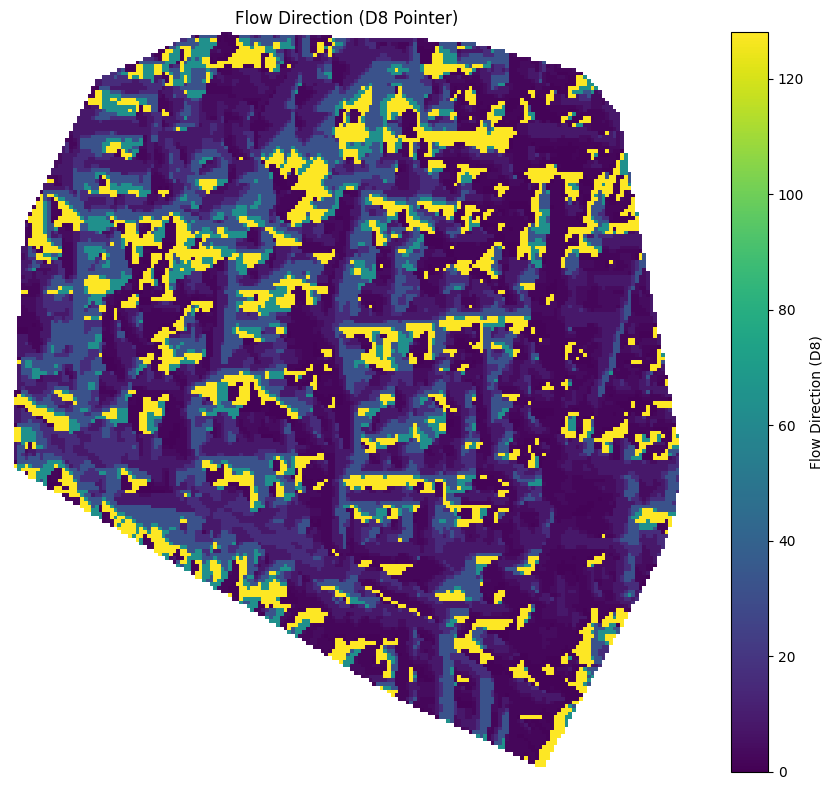

In [9]:
# ==========================================================
# FLOW DIRECTION
# ==========================================================
filled_tif = os.path.abspath(os.path.join(output_dir, "dtm_filled.tif"))
flow_dir_tif = os.path.abspath(os.path.join(output_dir, "flow_dir.tif"))

wbt.d8_pointer(
    dem=filled_tif,
    output=flow_dir_tif
)

print("✅ Flow direction saved →", flow_dir_tif)

# ==========================================================
# LOAD FLOW DIRECTION
# ==========================================================
import rasterio
import numpy as np
import matplotlib.pyplot as plt

flow_dir_tif = os.path.join(output_dir, "flow_dir.tif")

with rasterio.open(flow_dir_tif) as src:
    flow_dir = src.read(1).astype("float32")
    nodata = src.nodata
if nodata is not None:
    flow_dir[flow_dir == nodata] = np.nan

# ==========================================================
# PLOT FLOW DIRECTION
# ==========================================================
plt.figure(figsize=(10, 8))

plt.imshow(flow_dir, cmap="viridis")

plt.colorbar(label="Flow Direction (D8)")
plt.title("Flow Direction (D8 Pointer)")
plt.axis("off")
plt.tight_layout()
plt.show()

# Flow accumulation

./whitebox_tools --run="D8FlowAccumulation" --wd="/content" --input='/content/outputs/dtm_filled.tif' --output='/content/outputs/flow_acc.tif' --out_type=cells -v --compress_rasters=False

*********************************
* Welcome to D8FlowAccumulation *
* Powered by WhiteboxTools      *
* www.whiteboxgeo.com           *
*********************************
Reading data...
Flow directions: 0%
Flow directions: 1%
Flow directions: 2%
Flow directions: 3%
Flow directions: 4%
Flow directions: 5%
Flow directions: 6%
Flow directions: 7%
Flow directions: 8%
Flow directions: 9%
Flow directions: 10%
Flow directions: 11%
Flow directions: 12%
Flow directions: 13%
Flow directions: 14%
Flow directions: 15%
Flow directions: 16%
Flow directions: 17%
Flow directions: 18%
Flow directions: 19%
Flow directions: 20%
Flow directions: 21%
Flow directions: 22%
Flow directions: 23%
Flow directions: 24%
Flow directions: 25%
Flow directions: 26%
Flow directions: 27%
Flow directions: 28%
Flow directions: 29%
Flow 

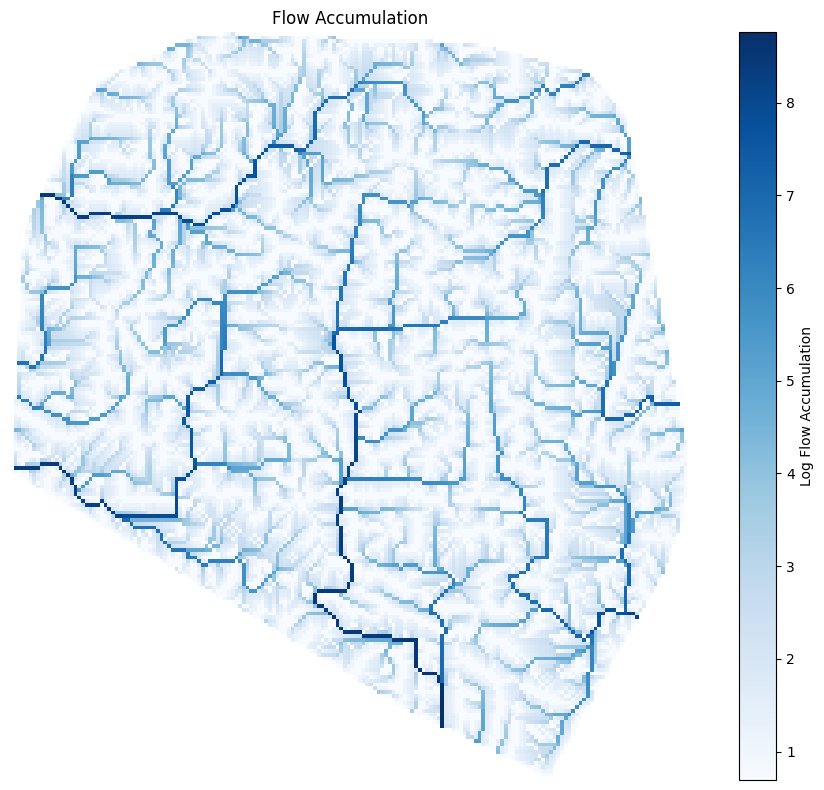

In [10]:
# ==========================================================
# FLOW ACCUMULATION
# ==========================================================
filled_tif = os.path.abspath(os.path.join(output_dir, "dtm_filled.tif"))
flow_acc_tif = os.path.abspath(os.path.join(output_dir, "flow_acc.tif"))

wbt.d8_flow_accumulation(
    i=filled_tif,
    output=flow_acc_tif,
    out_type="cells"
)

print("✅ Flow accumulation saved →", flow_acc_tif)

# ==========================================================
# LOAD FLOW ACCUMULATION
# ==========================================================
with rasterio.open(flow_acc_tif) as src:
    flow = src.read(1).astype("float32")
    nodata = src.nodata

if nodata is not None:
    flow[flow == nodata] = np.nan

flow[flow <= 0] = np.nan

# ==========================================================
# PLOT FLOW ACCUMULATION
# ==========================================================
flow_log = np.log1p(flow)   # VERY IMPORTANT

plt.figure(figsize=(10, 8))

plt.imshow(flow_log, cmap="Blues")

plt.colorbar(label="Log Flow Accumulation")
plt.title("Flow Accumulation")
plt.axis("off")
plt.tight_layout()
plt.show()

# Slope

./whitebox_tools --run="Slope" --wd="/content" --dem='/content/outputs/dtm_filled.tif' --output='/content/outputs/slope.tif' --units=degrees -v --compress_rasters=False

****************************
* Welcome to Slope         *
* Powered by WhiteboxTools *
* www.whiteboxgeo.com      *
****************************
Progress: 0%
Progress: 1%
Progress: 2%
Progress: 3%
Progress: 4%
Progress: 5%
Progress: 6%
Progress: 7%
Progress: 8%
Progress: 9%
Progress: 10%
Progress: 11%
Progress: 12%
Progress: 13%
Progress: 14%
Progress: 15%
Progress: 16%
Progress: 17%
Progress: 18%
Progress: 19%
Progress: 20%
Progress: 21%
Progress: 22%
Progress: 23%
Progress: 24%
Progress: 25%
Progress: 26%
Progress: 27%
Progress: 28%
Progress: 29%
Progress: 30%
Progress: 31%
Progress: 32%
Progress: 33%
Progress: 34%
Progress: 35%
Progress: 36%
Progress: 37%
Progress: 38%
Progress: 39%
Progress: 40%
Progress: 41%
Progress: 42%
Progress: 43%
Progress: 44%
Progress: 45%
Progress: 46%
Progress: 47%
Progress: 48%
Progress:

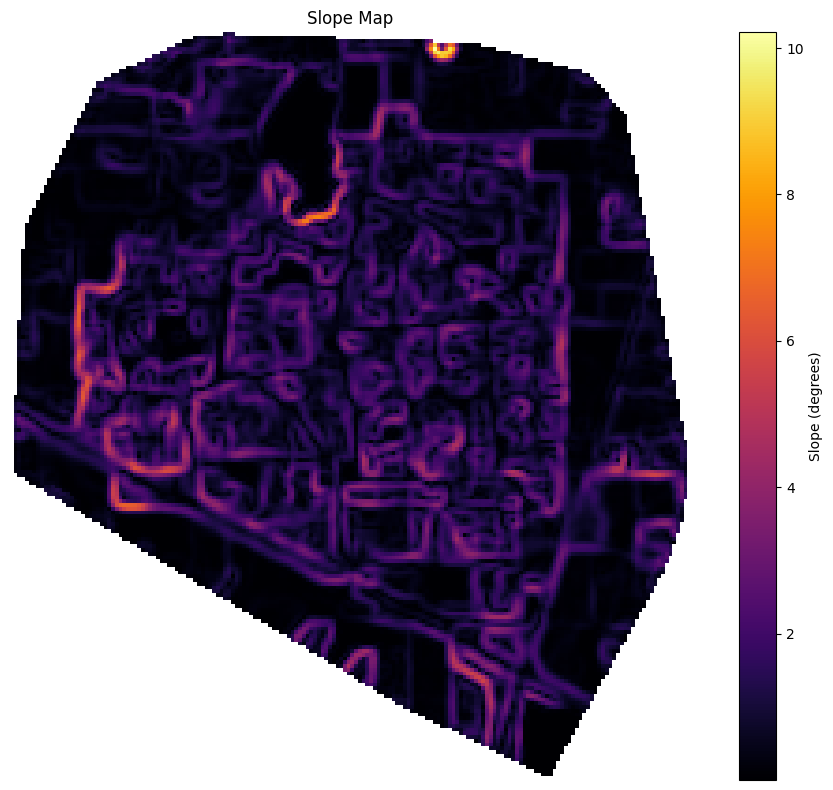

In [11]:
# ==========================================================
# SLOPE
# ==========================================================

filled_tif = os.path.abspath(os.path.join(output_dir, "dtm_filled.tif"))
slope_tif = os.path.abspath(os.path.join(output_dir, "slope.tif"))

wbt.slope(
    dem=filled_tif,
    output=slope_tif,
    units="degrees"
)

print("✅ Slope saved →", slope_tif)
with rasterio.open(slope_tif) as src:
    slope = src.read(1).astype("float32")
    nodata = src.nodata

if nodata is not None:
    slope[slope == nodata] = np.nan

plt.figure(figsize=(10, 8))
plt.imshow(slope, cmap="inferno")
plt.colorbar(label="Slope (degrees)")
plt.title("Slope Map")
plt.axis("off")
plt.tight_layout()
plt.show()

# TWI (Topographic Wetness Index)

./whitebox_tools --run="WetnessIndex" --wd="/content" --sca='/content/outputs/flow_acc.tif' --slope='/content/outputs/slope.tif' --output='/content/outputs/twi.tif' -v --compress_rasters=False

****************************
* Welcome to WetnessIndex  *
* Powered by WhiteboxTools *
* www.whiteboxgeo.com      *
****************************
Reading data...
Progress: 0%
Progress: 1%
Progress: 2%
Progress: 3%
Progress: 4%
Progress: 5%
Progress: 6%
Progress: 7%
Progress: 8%
Progress: 9%
Progress: 10%
Progress: 11%
Progress: 12%
Progress: 13%
Progress: 14%
Progress: 15%
Progress: 16%
Progress: 17%
Progress: 18%
Progress: 19%
Progress: 20%
Progress: 21%
Progress: 22%
Progress: 23%
Progress: 24%
Progress: 25%
Progress: 26%
Progress: 27%
Progress: 28%
Progress: 29%
Progress: 30%
Progress: 31%
Progress: 32%
Progress: 33%
Progress: 34%
Progress: 35%
Progress: 36%
Progress: 37%
Progress: 38%
Progress: 39%
Progress: 40%
Progress: 41%
Progress: 42%
Progress: 43%
Progress: 44%
Progress: 45%
Progress: 4

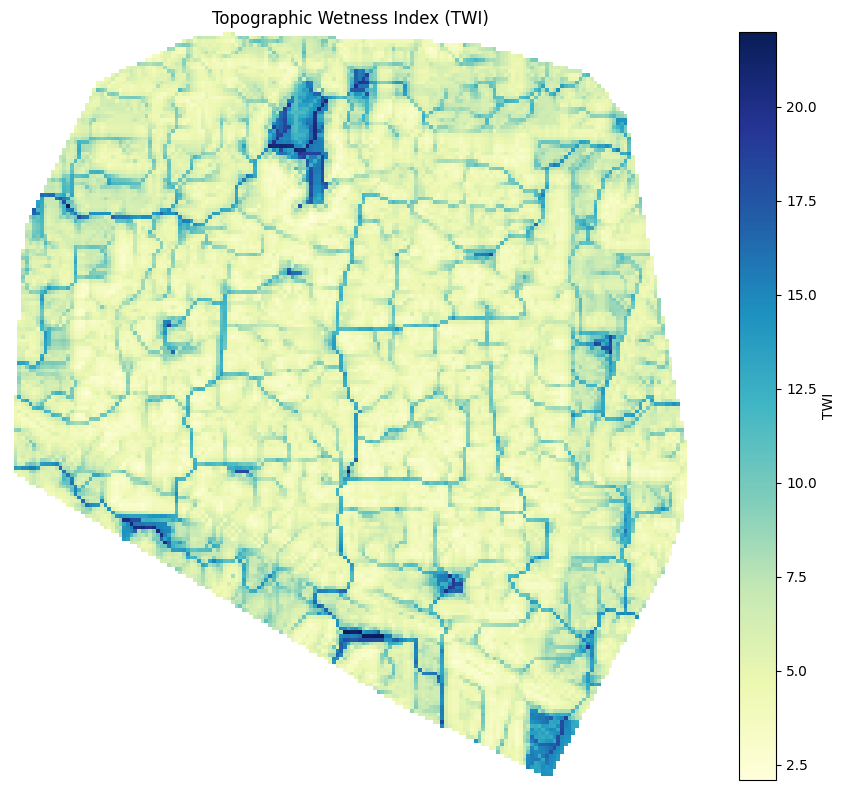

In [12]:
# ==========================================================
# TOPOGRAPHIC WETNESS INDEX (TWI)
# ==========================================================
flow_acc_tif = os.path.abspath(os.path.join(output_dir, "flow_acc.tif"))
slope_tif = os.path.abspath(os.path.join(output_dir, "slope.tif"))
twi_tif = os.path.abspath(os.path.join(output_dir, "twi.tif"))

wbt.wetness_index(
    sca=flow_acc_tif,
    slope=slope_tif,
    output=twi_tif
)

print("✅ TWI saved →", twi_tif)

with rasterio.open(twi_tif) as src:
    twi = src.read(1).astype("float32")
    nodata = src.nodata

if nodata is not None:
    twi[twi == nodata] = np.nan

plt.figure(figsize=(10, 8))
plt.imshow(twi, cmap="YlGnBu")
plt.colorbar(label="TWI")
plt.title("Topographic Wetness Index (TWI)")
plt.axis("off")
plt.tight_layout()
plt.show()

# HAND (Height Above Nearest Drainage)

./whitebox_tools --run="ExtractStreams" --wd="/content" --flow_accum='/content/outputs/flow_acc.tif' --output='/content/outputs/streams.tif' --threshold='1000' -v --compress_rasters=False

*****************************
* Welcome to ExtractStreams *
* Powered by WhiteboxTools  *
* www.whiteboxgeo.com       *
*****************************
Reading data...
Progress: 0%
Progress: 1%
Progress: 2%
Progress: 3%
Progress: 4%
Progress: 5%
Progress: 6%
Progress: 7%
Progress: 8%
Progress: 9%
Progress: 10%
Progress: 11%
Progress: 12%
Progress: 13%
Progress: 14%
Progress: 15%
Progress: 16%
Progress: 17%
Progress: 18%
Progress: 19%
Progress: 20%
Progress: 21%
Progress: 22%
Progress: 23%
Progress: 24%
Progress: 25%
Progress: 26%
Progress: 27%
Progress: 28%
Progress: 29%
Progress: 30%
Progress: 31%
Progress: 32%
Progress: 33%
Progress: 34%
Progress: 35%
Progress: 36%
Progress: 37%
Progress: 38%
Progress: 39%
Progress: 40%
Progress: 41%
Progress: 42%
Progress: 43%
Progress: 44%
Progress: 45%
Progress: 4

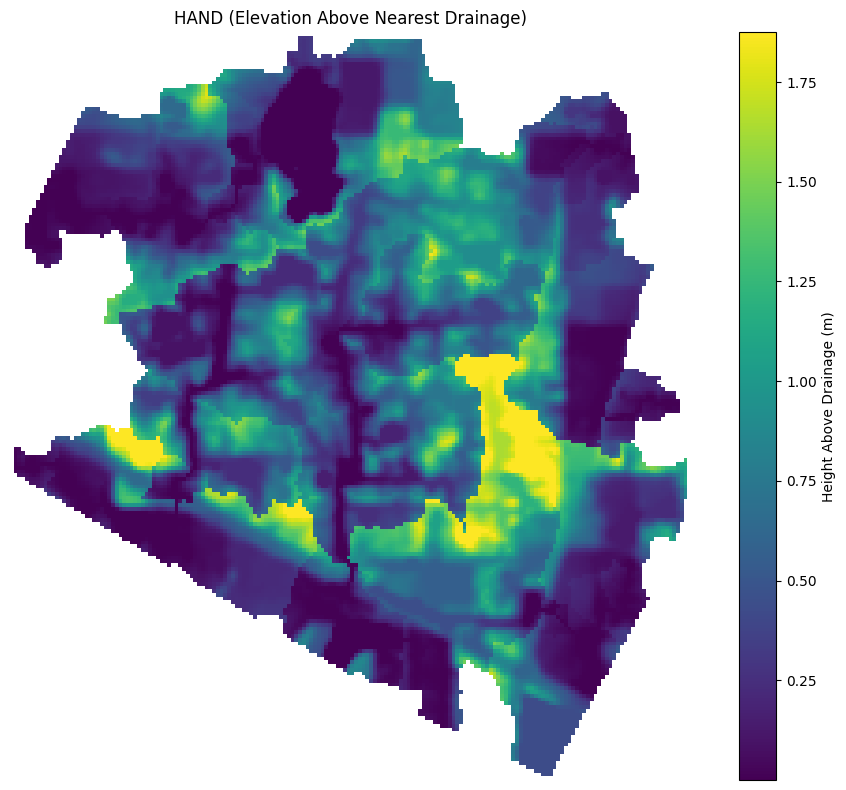

In [13]:
flow_acc_tif = os.path.abspath(os.path.join(output_dir, "flow_acc.tif"))
filled_tif   = os.path.abspath(os.path.join(output_dir, "dtm_filled.tif"))

streams_tif  = os.path.abspath(os.path.join(output_dir, "streams.tif"))
hand_tif     = os.path.abspath(os.path.join(output_dir, "hand.tif"))

# ----------------------------------------------------------
# Extract Streams
# ----------------------------------------------------------
wbt.extract_streams(
    flow_accum=flow_acc_tif,
    output=streams_tif,
    threshold=1000
)

print("✅ Streams raster →", streams_tif)


# ==========================================================
# LOAD HAND
# ==========================================================
wbt.elevation_above_stream(
    dem=filled_tif,
    streams=streams_tif,
    output=hand_tif
)

print("✅ HAND saved →", hand_tif)

with rasterio.open(hand_tif) as src:
    hand = src.read(1).astype("float32")
    nodata = src.nodata

if nodata is not None:
    hand[hand == nodata] = np.nan

plt.figure(figsize=(10, 8))

plt.imshow(
    hand,
    cmap="viridis",
    vmin=np.nanpercentile(hand, 2),
    vmax=np.nanpercentile(hand, 98)
)

plt.colorbar(label="Height Above Drainage (m)")
plt.title("HAND (Elevation Above Nearest Drainage)")
plt.axis("off")
plt.tight_layout()
plt.show()

# Load all the layers

In [14]:

import os
import rasterio
import numpy as np

def load_raster(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")
        nodata = src.nodata
    if nodata is not None:
        arr[arr == nodata] = np.nan
    return arr

# ==========================================================
# DEFINE PATHS
# ==========================================================
dem_path   = os.path.join(output_dir, "dtm_filled.tif")
slope_path = os.path.join(output_dir, "slope.tif")
twi_path   = os.path.join(output_dir, "twi.tif")
hand_path  = os.path.join(output_dir, "hand.tif")

# ==========================================================
#  LOAD RASTERS
# ==========================================================
dem   = load_raster(dem_path)
slope = load_raster(slope_path)
twi   = load_raster(twi_path)
hand  = load_raster(hand_path)

print("✅ All rasters loaded successfully")

✅ All rasters loaded successfully


# Normalise them

In [15]:
def normalize(x):
    min_val = np.nanmin(x)
    max_val = np.nanmax(x)

    if max_val - min_val == 0:
        return np.zeros_like(x)

    return (x - min_val) / (max_val - min_val)

twi_n   = normalize(twi)
slope_n = normalize(slope)
elev_n  = normalize(dem)
hand_n  = normalize(hand)

# Invertion is done where HIGH values are less suitable
slope_n = 1 - slope_n
elev_n  = 1 - elev_n
hand_n  = 1 - hand_n

# Weighted Model

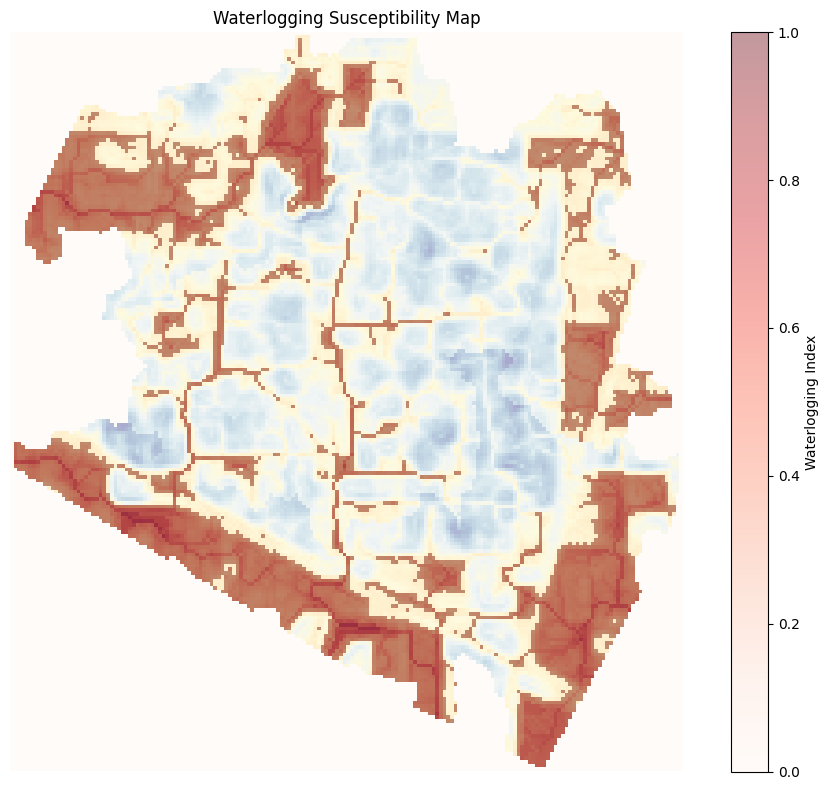

✅ Saved index → outputs/waterlogging_index.tif
✅ Saved hotspots → outputs/hotspots.tif


In [16]:
# ==========================================================
# COMPOSITE INDEX
# ==========================================================
index = (twi_n + slope_n + elev_n + hand_n) / 4

# Mask NoData
index[np.isnan(dem)] = np.nan

# ==========================================================
# HOTSPOTS
# ==========================================================
threshold = np.nanpercentile(index, 70)
hotspots = index >= threshold

# ==========================================================
# PLOT
# ==========================================================
plt.figure(figsize=(10,8))

plt.imshow(index, cmap="RdYlBu_r", alpha=0.7)
plt.imshow(hotspots, cmap="Reds", alpha=0.4)

plt.colorbar(label="Waterlogging Index")
plt.title("Waterlogging Susceptibility Map")
plt.axis("off")
plt.tight_layout()
plt.show()


index_tif = os.path.join(output_dir, "waterlogging_index.tif")

with rasterio.open(filled_tif) as src:
    meta = src.meta.copy()

meta.update(dtype="float32", nodata=np.nan)

with rasterio.open(index_tif, "w", **meta) as dst:
    dst.write(index.astype("float32"), 1)

print("✅ Saved index →", index_tif)

hotspot_tif = os.path.join(output_dir, "hotspots.tif")

meta.update(dtype="uint8", nodata=0)

with rasterio.open(hotspot_tif, "w", **meta) as dst:
    dst.write(hotspots.astype("uint8"), 1)

print("✅ Saved hotspots →", hotspot_tif)

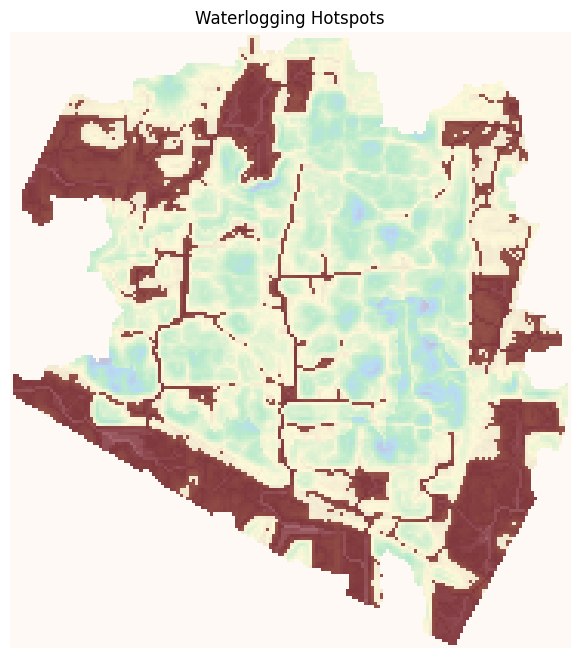

In [17]:
plt.figure(figsize=(10,8))

plt.imshow(index, cmap="terrain", alpha=0.7)
plt.imshow(hotspots, cmap="Reds", alpha=0.6)

plt.title("Waterlogging Hotspots")
plt.axis("off")
plt.show()

# Natural drainage network

./whitebox_tools --run="ExtractStreams" --wd="/content" --flow_accum='/content/outputs/flow_acc.tif' --output='/content/outputs/streams.tif' --threshold='10' -v --compress_rasters=False

*****************************
* Welcome to ExtractStreams *
* Powered by WhiteboxTools  *
* www.whiteboxgeo.com       *
*****************************
Reading data...
Progress: 0%
Progress: 1%
Progress: 2%
Progress: 3%
Progress: 4%
Progress: 5%
Progress: 6%
Progress: 7%
Progress: 8%
Progress: 9%
Progress: 10%
Progress: 11%
Progress: 12%
Progress: 13%
Progress: 14%
Progress: 15%
Progress: 16%
Progress: 17%
Progress: 18%
Progress: 19%
Progress: 20%
Progress: 21%
Progress: 22%
Progress: 23%
Progress: 24%
Progress: 25%
Progress: 26%
Progress: 27%
Progress: 28%
Progress: 29%
Progress: 30%
Progress: 31%
Progress: 32%
Progress: 33%
Progress: 34%
Progress: 35%
Progress: 36%
Progress: 37%
Progress: 38%
Progress: 39%
Progress: 40%
Progress: 41%
Progress: 42%
Progress: 43%
Progress: 44%
Progress: 45%
Progress: 46%

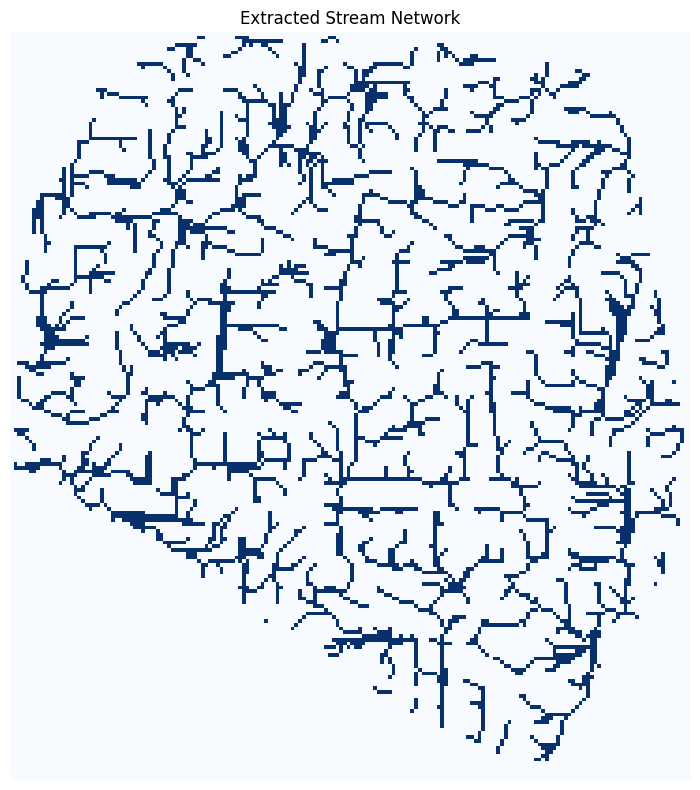

In [18]:
flow_acc_tif = os.path.abspath(os.path.join(output_dir, "flow_acc.tif"))
flow_dir_tif = os.path.abspath(os.path.join(output_dir, "flow_dir.tif"))

streams_tif = os.path.abspath(os.path.join(output_dir, "streams.tif"))
streams_shp = os.path.abspath(os.path.join(output_dir, "streams.shp"))

# ----------------------------------------------------------
# Extract Streams
# ----------------------------------------------------------
wbt.extract_streams(
    flow_accum=flow_acc_tif,
    output=streams_tif,
    threshold=10
)

print("✅ Streams raster →", streams_tif)

# ----------------------------------------------------------
# Raster → Vector
# ----------------------------------------------------------
wbt.raster_streams_to_vector(
    streams=streams_tif,
    d8_pntr=flow_dir_tif,
    output=streams_shp
)

print("✅ Streams vector →", streams_shp)
# ==========================================================
# LOAD STREAMS (FIXED PATH)
# ==========================================================
import os

streams_tif = os.path.join(output_dir, "streams.tif")

with rasterio.open(streams_tif) as src:
    streams = src.read(1)
    nodata = src.nodata

# Handle NoData
if nodata is not None:
    streams = np.where(streams == nodata, np.nan, streams)

# Convert to binary (important)
streams_bin = streams > 0

# ==========================================================
# PLOT STREAMS
# ==========================================================
plt.figure(figsize=(10, 8))

plt.imshow(streams_bin, cmap="Blues")

plt.title("Extracted Stream Network")
plt.axis("off")

plt.tight_layout()
plt.show()

# Overlay streams on hotspots

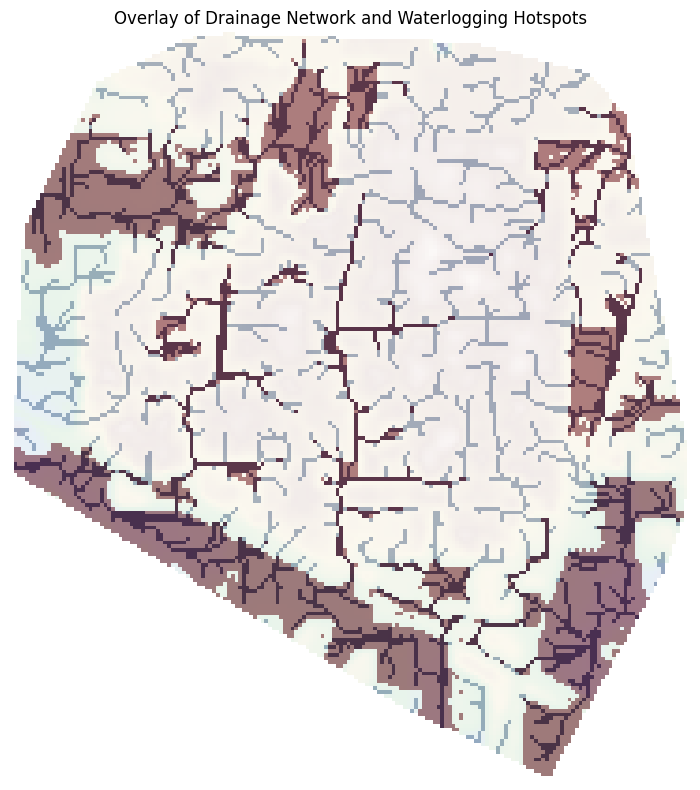

In [19]:

mask = np.isnan(dem)

streams_bin = np.where(mask, np.nan, streams_bin)
hotspots    = np.where(mask, np.nan, hotspots)


# ==========================================================
# OVERLAY: STREAMS + HOTSPOTS
# ==========================================================
plt.figure(figsize=(10, 8))

# DEM base
plt.imshow(dem, cmap="terrain", alpha=0.5)

# Streams (make them sharper)
plt.imshow(streams_bin, cmap="Blues", alpha=0.7)

# Hotspots (highlight clearly)
plt.imshow(hotspots, cmap="Reds", alpha=0.5)

plt.title("Overlay of Drainage Network and Waterlogging Hotspots")
plt.axis("off")

plt.tight_layout()
plt.show()



# Find Unconnected hotspots

DEM shape: (200, 182)
Hotspots shape: (200, 182)
Streams shape: (200, 182)
✅ Saved: unconnected_hotspots.tif


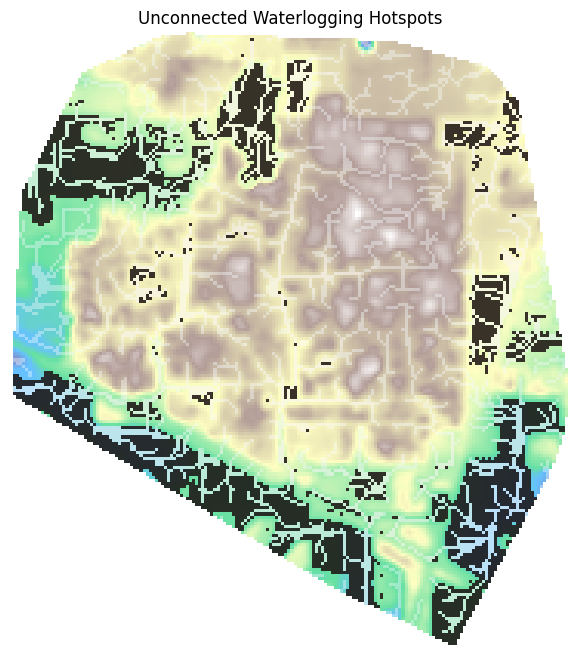

In [20]:
# ==========================================================
# IMPORTS
# ==========================================================
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# SAFETY CHECKS (VERY IMPORTANT)
# ==========================================================
print("DEM shape:", dem.shape)
print("Hotspots shape:", hotspots.shape)
print("Streams shape:", streams_bin.shape)

assert dem.shape == hotspots.shape == streams_bin.shape, "Raster dimensions do not match!"

# ==========================================================
# CONVERT TO BOOLEAN (SAFE GIS PRACTICE)
# ==========================================================
hotspots_bool = hotspots == 1
streams_bool = streams_bin == 1

# ==========================================================
# FIND UNCONNECTED HOTSPOTS
# ==========================================================
unconnected = np.logical_and(hotspots_bool, np.logical_not(streams_bool))

# ==========================================================
# VISUALIZATION
# ==========================================================

with rasterio.open(
    "unconnected_hotspots.tif",
    "w",
    driver="GTiff",
    height=unconnected.shape[0],
    width=unconnected.shape[1],
    count=1,
    dtype="uint8",
    crs=src.crs,              # uses reference raster
    transform=src.transform
) as dst:
    dst.write(unconnected.astype("uint8"), 1)

print("✅ Saved: unconnected_hotspots.tif")



plt.figure(figsize=(10, 8))

# Base DEM
plt.imshow(dem, cmap="terrain", alpha=0.6)

# Streams (optional background layer)
plt.imshow(np.where(streams_bool, 1, np.nan),
           cmap="Blues", alpha=0.4)

# All hotspots (optional faint layer)
plt.imshow(np.where(hotspots_bool, 1, np.nan),
           cmap="Reds", alpha=0.3)

# Unconnected hotspots (MAIN RESULT)
plt.imshow(np.where(unconnected, 1, np.nan),
           cmap="hot", alpha=0.8)

plt.title("Unconnected Waterlogging Hotspots")
plt.axis("off")

plt.show()

# Workflow for alternate drainage network

Working dir: /content/outputs
Files: ['flow_dir.tif', 'flow_acc.tif', 'streams.dbf', 'hotspots.tif', 'twi.tif', 'waterlogging_index.tif', 'streams.tif', 'streams.shp', 'slope.tif', 'dtm_filled.tif', 'streams.shx', 'hand.tif']
✅ cost.tif saved
✅ targets.tif saved
./whitebox_tools --run="CostDistance" --wd="/content/outputs" --source='streams.tif' --cost='cost.tif' --out_accum='cost_dist.tif' --out_backlink='backlink.tif' -v --compress_rasters=False

****************************
* Welcome to CostDistance  *
* Powered by WhiteboxTools *
* www.whiteboxgeo.com      *
****************************
Reading source data...
Reading cost data...
Initializing: 0%
Initializing: 1%
Initializing: 2%
Initializing: 3%
Initializing: 4%
Initializing: 5%
Initializing: 6%
Initializing: 7%
Initializing: 8%
Initializing: 9%
Initializing: 10%
Initializing: 11%
Initializing: 12%
Initializing: 13%
Initializing: 14%
Initializing: 15%
Initializing: 16%
Initializing: 17%
Initializing: 18%
Initializing: 19%
Initiali

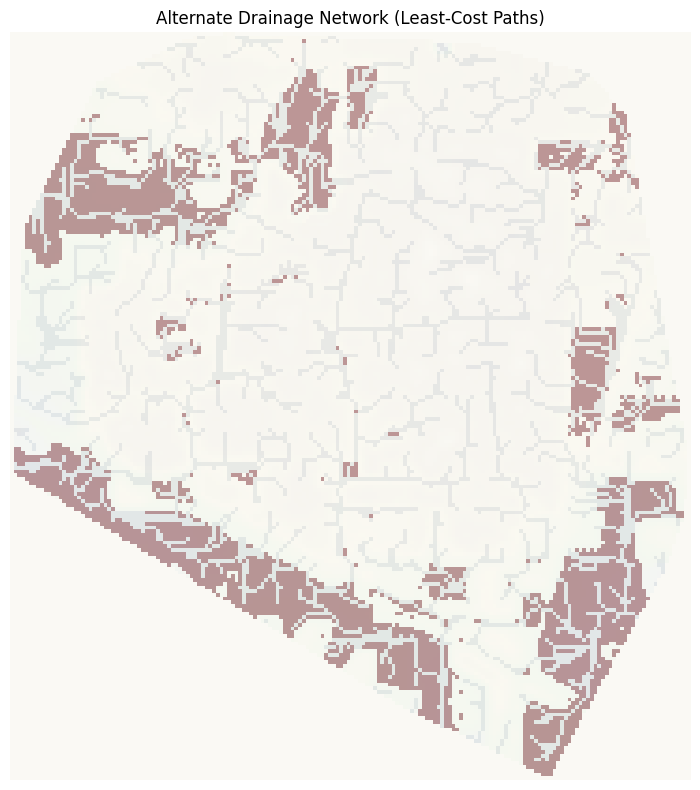

In [22]:
# ==========================================================
# IMPORTS
# ==========================================================
import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from whitebox.whitebox_tools import WhiteboxTools

# ==========================================================
# SET WORKING DIRECTORY (IMPORTANT)
# ==========================================================
work_dir = "/content/outputs"

os.chdir(work_dir)
print("Working dir:", os.getcwd())
print("Files:", os.listdir())


# ==========================================================
# INPUT FILES (MAKE SURE THEY EXIST HERE)
# ==========================================================
dem_file      = "dtm_filled.tif"
slope_file    = "slope.tif"
hand_file     = "hand.tif"
streams_file  = "streams.tif"
hotspots_file = "hotspots.tif"

# ==========================================================
# LOAD RASTERS
# ==========================================================
def read_raster(file):
    with rasterio.open(file) as src:
        data = src.read(1)
        profile = src.profile
        nodata = src.nodata
    if nodata is not None:
        data = np.where(data == nodata, np.nan, data)
    return data, profile

dem, profile = read_raster(dem_file)
slope, _     = read_raster(slope_file)
hand, _      = read_raster(hand_file)
streams, _   = read_raster(streams_file)
hotspots, _  = read_raster(hotspots_file)

# Binary masks
streams_bin  = streams > 0
hotspots_bin = hotspots == 1

# ==========================================================
# NORMALIZATION FUNCTION
# ==========================================================
def normalize(x):
    return (x - np.nanmin(x)) / (np.nanmax(x) - np.nanmin(x))

# ==========================================================
# NORMALIZE FACTORS
# ==========================================================
slope_n = 1 - normalize(slope)   # low slope preferred
hand_n  = 1 - normalize(hand)    # low HAND preferred
elev_n  = 1 - normalize(dem)     # low elevation preferred

# ==========================================================
# COST SURFACE
# ==========================================================
cost = (
    0.5 * slope_n +
    0.3 * hand_n +
    0.2 * elev_n
)

# Replace nan with high cost
cost[np.isnan(cost)] = 9999

# ==========================================================
# SAVE COST RASTER
# ==========================================================
cost_profile = profile.copy()
cost_profile.update(dtype="float32", nodata=9999)

with rasterio.open("cost.tif", "w", **cost_profile) as dst:
    dst.write(cost.astype("float32"), 1)

print("✅ cost.tif saved")

# ==========================================================
# IDENTIFY UNCONNECTED HOTSPOTS
# ==========================================================
unconnected = hotspots_bin & (~streams_bin)

targets = unconnected.astype("int32")

target_profile = profile.copy()
target_profile.update(dtype="int32", nodata=0)

with rasterio.open("targets.tif", "w", **target_profile) as dst:
    dst.write(targets, 1)

print("✅ targets.tif saved")

# ==========================================================
# INIT WHITEBOXTOOLS
# ==========================================================
wbt = WhiteboxTools()
wbt.set_working_dir(work_dir)
wbt.verbose = True

# ==========================================================
# COST DISTANCE
# ==========================================================
wbt.cost_distance(
    source=streams_file,
    cost="cost.tif",
    out_accum="cost_dist.tif",
    out_backlink="backlink.tif"
)

print("✅ Cost distance completed")

# ==========================================================
# LEAST-COST PATH (ALTERNATE DRAINAGE)
# ==========================================================
wbt.cost_pathway(
    destination="targets.tif",
    backlink="backlink.tif",
    output="drain_alternative.tif"
)

print("✅ Drainage paths generated")

# ==========================================================
# LOAD OUTPUT
# ==========================================================
with rasterio.open("drain_alternative.tif") as src:
    drains = src.read(1)
    nodata = src.nodata

if nodata is not None:
    drains = np.where(drains == nodata, np.nan, drains)

drains_bin = drains > 0

# ==========================================================
# VISUALIZATION
# ==========================================================
plt.figure(figsize=(10, 8))

plt.imshow(dem, cmap="terrain", alpha=0.5)
plt.imshow(streams_bin, cmap="Blues", alpha=0.6)
plt.imshow(drains_bin, cmap="Greens", alpha=0.8)
plt.imshow(unconnected, cmap="Reds", alpha=0.4)

plt.title("Alternate Drainage Network (Least-Cost Paths)")
plt.axis("off")
plt.tight_layout()
plt.show()

# Converting rasters into vectors

In [23]:
# ==========================================================
# RASTER → POLYGON (HOTSPOTS + INDEX)
# ==========================================================
wbt.raster_to_vector_polygons(
    i="waterlogging_index.tif",
    output="waterlogging_index.shp"
)

wbt.raster_to_vector_polygons(
    i="hotspots.tif",
    output="hotspots.shp"
)

print("✅ polygons created")

# ==========================================================
# DRAINAGE → VECTOR (LINES)
# ==========================================================
# IMPORTANT: convert boolean to proper stream raster
drains_clean = drains_bin.astype("int32")

profile.update(dtype="int32", nodata=0)

with rasterio.open("drain_streams.tif", "w", **profile) as dst:
    dst.write(drains_clean, 1)

print("✅ drain_streams.tif created")

# ==========================================================
# VECTORIZE DRAINAGE
# ==========================================================
wbt.raster_streams_to_vector(
    streams="drain_streams.tif",
    d8_pntr="flow_dir.tif",
    output="alternative_drainage.shp"
)

print("✅ alternative drainage shapefile created")

./whitebox_tools --run="RasterToVectorPolygons" --wd="/content/outputs" --input='waterlogging_index.tif' --output='waterlogging_index.shp' -v --compress_rasters=False

*************************************
* Welcome to RasterToVectorPolygons *
* Powered by WhiteboxTools          *
* www.whiteboxgeo.com               *
*************************************
Reading data...
Clumping polygons: 0%
Clumping polygons: 1%
Clumping polygons: 2%
Clumping polygons: 3%
Clumping polygons: 4%
Clumping polygons: 5%
Clumping polygons: 6%
Clumping polygons: 7%
Clumping polygons: 8%
Clumping polygons: 9%
Clumping polygons: 10%
Clumping polygons: 11%
Clumping polygons: 12%
Clumping polygons: 13%
Clumping polygons: 14%
Clumping polygons: 15%
Clumping polygons: 16%
Clumping polygons: 17%
Clumping polygons: 18%
Clumping polygons: 19%
Clumping polygons: 20%
Clumping polygons: 21%
Clumping polygons: 22%
Clumping polygons: 23%
Clumping polygons: 24%
Clumping polygons: 25%
Clumping polygons: 26%
Clumping polygo

✅ drain_streams.tif created
./whitebox_tools --run="RasterStreamsToVector" --wd="/content/outputs" --streams='drain_streams.tif' --d8_pntr='flow_dir.tif' --output='alternative_drainage.shp' -v --compress_rasters=False

************************************
* Welcome to RasterStreamsToVector *
* Powered by WhiteboxTools         *
* www.whiteboxgeo.com              *
************************************
Reading pointer data...
Reading streams data...
Progress: 0%
Saving data...
Output file written
Elapsed Time (excluding I/O): 0.50s
✅ alternative drainage shapefile created


# Convert all the shapefiles into the geopackage

In [28]:
import os
import subprocess

# Install GDAL tools if not already installed
try:
    subprocess.run(["ogr2ogr", "--version"], check=True, capture_output=True)
except FileNotFoundError:
    print("ogr2ogr not found. Installing gdal-bin...")
    subprocess.run(["apt-get", "update"], check=True)
    subprocess.run(["apt-get", "install", "-y", "gdal-bin"], check=True)
    print("gdal-bin installed.")

# ==========================================================
# USE CURRENT DIRECTORY
# ==========================================================
folder = "."   #

gpkg_file = os.path.join(folder, "final_outputs.gpkg")

first = True

# delete old file if exists
if os.path.exists(gpkg_file):
    os.remove(gpkg_file)

for file in os.listdir(folder):

    if file.endswith(".shp"):

        full_path = os.path.join(folder, file)
        layer_name = os.path.splitext(file)[0]

        cmd = [
            "ogr2ogr",
            "-f", "GPKG",
            gpkg_file,
            full_path,
            "-nln", layer_name
        ]

        if not first:
            cmd.insert(4, "-append")

        subprocess.run(cmd, check=True)

        print(f"Added {file} \u2192 layer: {layer_name}")

        first = False

print("\n All shapefiles saved into:", gpkg_file)

ogr2ogr not found. Installing gdal-bin...
gdal-bin installed.
Added waterlogging_index.shp → layer: waterlogging_index
Added alternative_drainage.shp → layer: alternative_drainage
Added hotspots.shp → layer: hotspots
Added streams.shp → layer: streams

 All shapefiles saved into: ./final_outputs.gpkg


# Converting all the TIFFs into COG format

In [29]:
# ==========================================================
# IMPORTS
# ==========================================================
import os
import subprocess

# ==========================================================
# FUNCTION: Convert TIFFs to COG
# ==========================================================
def convert_all_to_cog(
    input_folder=".",
    output_folder="cog",
    compress="LZW",
    validate=True
):
    """
    Converts all .tif files in input_folder to Cloud Optimized GeoTIFF (COG)
    and saves them in output_folder.

    Parameters:
        input_folder (str): Path to input rasters
        output_folder (str): Folder to save COGs
        compress (str): Compression type (LZW / DEFLATE)
        validate (bool): Whether to run gdalinfo check
    """

    # ------------------------------------------------------
    # Create output folder
    # ------------------------------------------------------
    os.makedirs(output_folder, exist_ok=True)

    print(f"\n📂 Input folder : {os.path.abspath(input_folder)}")
    print(f"📁 Output folder: {os.path.abspath(output_folder)}\n")

    converted = 0
    skipped = 0

    # ------------------------------------------------------
    # Loop through files
    # ------------------------------------------------------
    for file in os.listdir(input_folder):

        # Only process .tif (ignore already converted)
        if file.endswith(".tif") and not file.endswith("_cog.tif"):

            input_path = os.path.join(input_folder, file)

            output_name = file.replace(".tif", "_cog.tif")
            output_path = os.path.join(output_folder, output_name)

            # Skip if already exists
            if os.path.exists(output_path):
                print(f"⏭️ Skipped (exists): {output_name}")
                skipped += 1
                continue

            print(f"🔄 Converting: {file}")

            # --------------------------------------------------
            # GDAL command
            # --------------------------------------------------
            cmd = [
                "gdal_translate",
                input_path,
                output_path,
                "-of", "COG",
                "-co", f"COMPRESS={compress}",
                "-co", "BIGTIFF=IF_SAFER"
            ]

            subprocess.run(cmd, check=True)

            # --------------------------------------------------
            # Validate COG
            # --------------------------------------------------
            if validate:
                info = subprocess.check_output(["gdalinfo", output_path]).decode()

                if "COG" in info or "Cloud Optimized GeoTIFF" in info:
                    print(f"✅ Valid COG: {output_name}")
                else:
                    print(f"⚠️ Check manually: {output_name}")

            print(f"💾 Saved → {output_path}\n")

            converted += 1

    # ------------------------------------------------------
    # SUMMARY
    # ------------------------------------------------------
    print("\n🎉 COG Conversion Complete")
    print(f"✔ Converted: {converted}")
    print(f"⏭️ Skipped  : {skipped}")
    print(f"📁 Output   : {os.path.abspath(output_folder)}")


# ==========================================================
# RUN THE FUNCTION
# ==========================================================
if __name__ == "__main__":

    #  inside 'outputs' folder:
    convert_all_to_cog(input_folder=".", output_folder="cog")



📂 Input folder : /content/outputs
📁 Output folder: /content/outputs/cog

🔄 Converting: drain_alternative.tif
✅ Valid COG: drain_alternative_cog.tif
💾 Saved → cog/drain_alternative_cog.tif

🔄 Converting: flow_dir.tif
✅ Valid COG: flow_dir_cog.tif
💾 Saved → cog/flow_dir_cog.tif

🔄 Converting: flow_acc.tif
✅ Valid COG: flow_acc_cog.tif
💾 Saved → cog/flow_acc_cog.tif

🔄 Converting: drain_streams.tif
✅ Valid COG: drain_streams_cog.tif
💾 Saved → cog/drain_streams_cog.tif

🔄 Converting: backlink.tif
✅ Valid COG: backlink_cog.tif
💾 Saved → cog/backlink_cog.tif

🔄 Converting: hotspots.tif
✅ Valid COG: hotspots_cog.tif
💾 Saved → cog/hotspots_cog.tif

🔄 Converting: twi.tif
✅ Valid COG: twi_cog.tif
💾 Saved → cog/twi_cog.tif

🔄 Converting: targets.tif
✅ Valid COG: targets_cog.tif
💾 Saved → cog/targets_cog.tif

🔄 Converting: waterlogging_index.tif
✅ Valid COG: waterlogging_index_cog.tif
💾 Saved → cog/waterlogging_index_cog.tif

🔄 Converting: streams.tif
✅ Valid COG: streams_cog.tif
💾 Saved → cog/st